# Planejamento experimental, pós-testes e ANOVA fatorial

Este notebook é o **laboratório prático** da aula de planejamento experimental:

1. Cálculo amostral e simulação de poder
2. ANOVA com diferentes pós-testes (Tukey, Dunnett, Bonferroni)
3. Kruskal–Wallis + Dunn (não-paramétrico)
4. Planejamento fatorial 2 × 2 (ANOVA two-way + interação)

Todos os exemplos são reproduzíveis (seed fixa) e geram gráficos.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.power import TTestIndPower, FTestAnovaPower
import scikit_posthocs as sp

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size']  = 12
rng = np.random.default_rng(42)

## 1. Cálculo amostral

Quantos sujeitos preciso para ter 80 % de poder de detectar um efeito
de tamanho **d = 0,5** (Cohen) num teste t bicaudal com α = 0,05?

Usamos `statsmodels.stats.power.TTestIndPower.solve_power`.

In [2]:
analise = TTestIndPower()

for d in [0.2, 0.5, 0.8]:
    n = analise.solve_power(effect_size=d, alpha=0.05, power=0.80,
                            alternative='two-sided')
    print(f'd = {d}  →  n ≈ {np.ceil(n):.0f} por grupo')

d = 0.2  →  n ≈ 394 por grupo
d = 0.5  →  n ≈ 64 por grupo
d = 0.8  →  n ≈ 26 por grupo


### Curva de poder × n

Para visualizar como o poder cresce com o n para diferentes efeitos:

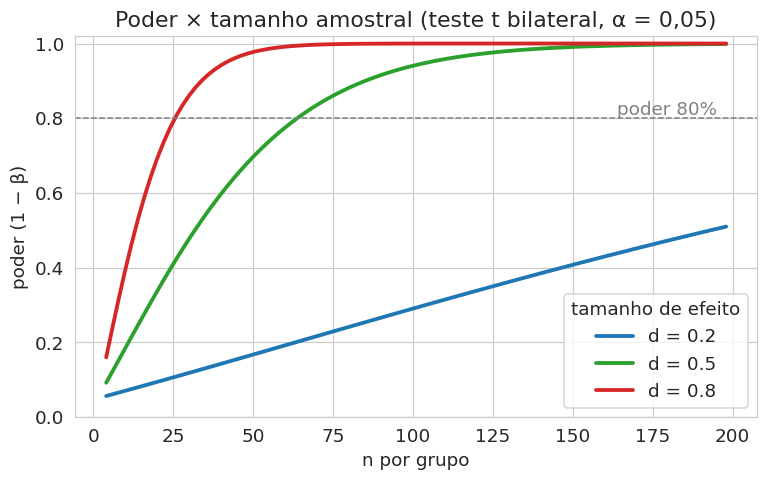

In [3]:
ns = np.arange(4, 200, 2)
fig, ax = plt.subplots(figsize=(8, 4.5))
for d, cor in [(0.2, 'C0'), (0.5, 'C2'), (0.8, 'C3')]:
    poder = analise.power(effect_size=d, nobs1=ns, alpha=0.05,
                          alternative='two-sided')
    ax.plot(ns, poder, lw=2.5, color=cor, label=f'd = {d}')
ax.axhline(0.8, color='gray', ls='--', lw=1)
ax.text(195, 0.81, 'poder 80%', ha='right', color='gray')
ax.set_xlabel('n por grupo')
ax.set_ylabel('poder (1 − β)')
ax.set_title('Poder × tamanho amostral (teste t bilateral, α = 0,05)')
ax.legend(title='tamanho de efeito', loc='lower right')
ax.set_ylim(0, 1.02);

### Simulação de poder via Monte Carlo

Comprovamos o poder rodando o experimento **muitas vezes** e contando em
quantos rejeitamos H₀. A fração observada é o poder empírico.

In [4]:
def poder_empirico(n, d, nsim=5000, alpha=0.05, seed=0):
    g = np.random.default_rng(seed)
    rejeicoes = 0
    for _ in range(nsim):
        x = g.normal(0, 1, n)
        y = g.normal(d, 1, n)
        _, p = stats.ttest_ind(x, y, equal_var=False)
        rejeicoes += (p < alpha)
    return rejeicoes / nsim

for n in [16, 32, 64]:
    p = poder_empirico(n, d=0.5)
    teo = analise.power(effect_size=0.5, nobs1=n, alpha=0.05)
    print(f'n = {n:>3}   empírico = {p:.3f}   teórico = {teo:.3f}')

n =  16   empírico = 0.275   teórico = 0.278


n =  32   empírico = 0.498   teórico = 0.504


n =  64   empírico = 0.805   teórico = 0.801


## 2. ANOVA one-way e diferentes pós-testes

Simulamos um experimento com **quatro grupos**: um controle (μ = 10)
e três tratamentos com efeitos diferentes.

In [5]:
np.random.seed(7)
n = 18
dados = pd.DataFrame({
    'grupo':    np.repeat(['controle', 'trat A', 'trat B', 'trat C'], n),
    'resposta': np.concatenate([
        np.random.normal(10.0, 2.0, n),   # controle
        np.random.normal(10.3, 2.0, n),   # quase igual ao controle
        np.random.normal(12.0, 2.0, n),   # diferença média
        np.random.normal(13.5, 2.0, n),   # diferença forte
    ])
})
dados.groupby('grupo')['resposta'].agg(['mean', 'std', 'count']).round(2)

,mean,std,count
grupo,,,
controle,9.91,1.65,18
trat A,9.76,2.49,18
trat B,12.39,2.34,18
trat C,12.97,1.97,18


/tmp/ipykernel_5535/3609580786.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dados, x='grupo', y='resposta', ax=ax,


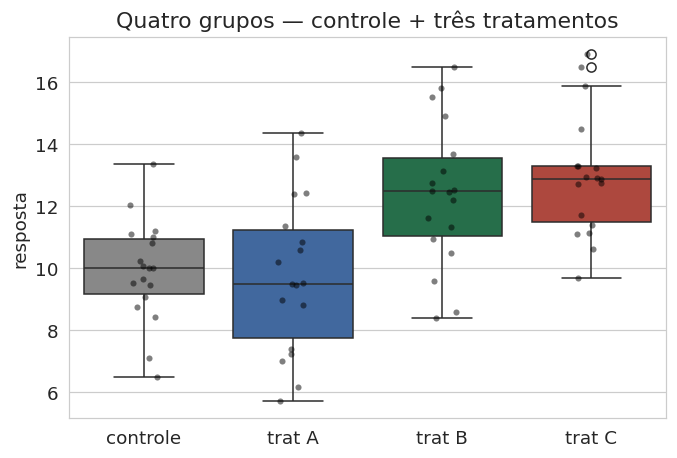

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.boxplot(data=dados, x='grupo', y='resposta', ax=ax,
            palette=['#888', '#3266ad', '#1a7a4a', '#c0392b'])
sns.stripplot(data=dados, x='grupo', y='resposta', ax=ax,
              color='black', alpha=0.5, size=4)
ax.set_title('Quatro grupos — controle + três tratamentos')
ax.set_xlabel(''); ax.set_ylabel('resposta');

### 2.1 ANOVA one-way

Primeiro o F-test global: alguma média difere?

In [7]:
modelo = smf.ols('resposta ~ C(grupo)', data=dados).fit()
anova  = sm.stats.anova_lm(modelo, typ=2)
print(anova)
print(f'\np global = {anova["PR(>F)"].iloc[0]:.4g}')

              sum_sq    df          F    PR(>F)
C(grupo)  149.486575   3.0  10.910584  0.000006
Residual  310.557369  68.0        NaN       NaN

p global = 6.15e-06


F significativo → vamos aos **pós-testes**. A escolha depende da pergunta:

| Pergunta | Pós-teste |
| --- | --- |
| comparar **todos** os grupos entre si | Tukey HSD |
| comparar **cada tratamento com o controle** | Dunnett |
| **poucas comparações planejadas** a priori | Bonferroni / Šidák |

### 2.2 Tukey HSD — todos × todos

In [8]:
tukey = pairwise_tukeyhsd(endog=dados['resposta'],
                          groups=dados['grupo'], alpha=0.05)
print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1  group2 meandiff p-adj   lower  upper  reject
-----------------------------------------------------
controle trat A  -0.1493 0.9967 -2.0255 1.7268  False
controle trat B   2.4853 0.0046  0.6092 4.3615   True
controle trat C   3.0662 0.0003  1.1901 4.9423   True
  trat A trat B   2.6347 0.0024  0.7585 4.5108   True
  trat A trat C   3.2155 0.0001  1.3394 5.0917   True
  trat B trat C   0.5809  0.847 -1.2953  2.457  False
-----------------------------------------------------

In [9]:
# tabela como DataFrame para inspecionar
tukey_df = pd.DataFrame(data=tukey._results_table.data[1:],
                        columns=tukey._results_table.data[0])
tukey_df

,group1,group2,meandiff,p-adj,lower,upper,reject
0,controle,trat A,-0.1493,0.9967,-2.0255,1.7268,False
1,controle,trat B,2.4853,0.0046,0.6092,4.3615,True
2,controle,trat C,3.0662,0.0003,1.1901,4.9423,True
3,trat A,trat B,2.6347,0.0024,0.7585,4.5108,True
4,trat A,trat C,3.2155,0.0001,1.3394,5.0917,True
5,trat B,trat C,0.5809,0.8470,-1.2953,2.4570,False


### 2.3 Dunnett — cada tratamento × controle

`scipy.stats.dunnett` (scipy ≥ 1.11) testa **só** as comparações com
o controle, gastando menos α-budget que Tukey.

In [10]:
ctrl = dados.loc[dados['grupo'] == 'controle', 'resposta'].values
amostras = [dados.loc[dados['grupo'] == g, 'resposta'].values
            for g in ['trat A', 'trat B', 'trat C']]

res = stats.dunnett(*amostras, control=ctrl, alternative='two-sided')
for g, est, p in zip(['trat A', 'trat B', 'trat C'], res.statistic, res.pvalue):
    sig = '★' if p < 0.05 else ' '
    print(f'{g:<10}  t = {est:+.3f}   p = {p:.4f}  {sig}')

trat A      t = -0.210   p = 0.9935   
trat B      t = +3.489   p = 0.0024  ★
trat C      t = +4.304   p = 0.0002  ★


### 2.4 Bonferroni — poucas comparações planejadas

Suponha que **antes** de coletar tínhamos só duas comparações de interesse:
controle × trat A  e  controle × trat C. Aplicamos t-tests pareados e
ajustamos por Bonferroni (k = 2).

In [11]:
from itertools import combinations

comparacoes = [('controle', 'trat A'), ('controle', 'trat C')]
k = len(comparacoes)
linhas = []
for g1, g2 in comparacoes:
    x = dados.loc[dados['grupo'] == g1, 'resposta']
    y = dados.loc[dados['grupo'] == g2, 'resposta']
    t, p = stats.ttest_ind(x, y, equal_var=False)
    linhas.append({'comparação': f'{g1} × {g2}',
                   't': t, 'p bruto': p,
                   'p × k': min(p * k, 1.0),
                   'sig?': '★' if p * k < 0.05 else ' '})
pd.DataFrame(linhas).round(4)

,comparação,t,p bruto,p × k,sig?
0,controle × trat A,0.2124,0.8333,1.0,
1,controle × trat C,-5.0600,0.0000,0.0,★


### 2.5 Comparando os três pós-testes lado a lado

In [12]:
# pega só os p para comparação

comp_alvo = [('controle', 'trat A'), ('controle', 'trat B'), ('controle', 'trat C')]

ps_tukey = {}
for _, row in tukey_df.iterrows():
    par = tuple(sorted([row['group1'], row['group2']]))
    ps_tukey[par] = float(row['p-adj'])

ps_dunnett = dict(zip(['trat A', 'trat B', 'trat C'], res.pvalue))

ps_bonf = {}
for g1, g2 in comp_alvo:
    x = dados.loc[dados['grupo'] == g1, 'resposta']
    y = dados.loc[dados['grupo'] == g2, 'resposta']
    _, p = stats.ttest_ind(x, y, equal_var=False)
    ps_bonf[g2] = min(p * len(comp_alvo), 1.0)

tabela = pd.DataFrame({
    'comparação': [f'controle × {g}' for _, g in comp_alvo],
    'Tukey HSD':  [ps_tukey[tuple(sorted(('controle', g)))] for _, g in comp_alvo],
    'Dunnett':    [ps_dunnett[g] for _, g in comp_alvo],
    'Bonferroni': [ps_bonf[g]    for _, g in comp_alvo],
}).round(4)
tabela

,comparação,Tukey HSD,Dunnett,Bonferroni
0,controle × trat A,0.9967,0.9935,1.0000
1,controle × trat B,0.0046,0.0024,0.0026
2,controle × trat C,0.0003,0.0002,0.0000


Note como cada método dá um **p-valor diferente** para a *mesma* comparação:
Dunnett tende a ser mais poderoso quando o interesse é só × controle,
Tukey corrige para todas as ⁽n₂⁾ = 6 comparações,
Bonferroni só corrige pelas k = 3 comparações planejadas.

## 3. Não-paramétrico: Kruskal–Wallis + Dunn

Se a normalidade falha (ou os dados são ordinais), trocamos a ANOVA pelo
Kruskal–Wallis e o pós-teste de Tukey pelo Dunn (com correção de Bonferroni).

Geramos dados com cauda pesada para ilustrar:

In [13]:
np.random.seed(11)
n = 20
dados_np = pd.DataFrame({
    'grupo':    np.repeat(['A', 'B', 'C', 'D'], n),
    'resposta': np.concatenate([
        stats.lognorm.rvs(0.7, size=n, loc=2),
        stats.lognorm.rvs(0.7, size=n, loc=2),
        stats.lognorm.rvs(0.7, size=n, loc=3.5),
        stats.lognorm.rvs(0.7, size=n, loc=5),
    ])
})

h, p = stats.kruskal(*[dados_np.loc[dados_np['grupo'] == g, 'resposta']
                       for g in ['A', 'B', 'C', 'D']])
print(f'Kruskal–Wallis  H = {h:.3f}   p = {p:.4g}')

Kruskal–Wallis  H = 57.650   p = 1.867e-12


In [14]:
dunn = sp.posthoc_dunn(dados_np, val_col='resposta', group_col='grupo',
                       p_adjust='bonferroni')
dunn.round(4)

,A,B,C,D
A,1.0000,1.0000,0.0008,0.0000
B,1.0000,1.0000,0.0096,0.0000
C,0.0008,0.0096,1.0000,0.0225
D,0.0000,0.0000,0.0225,1.0000


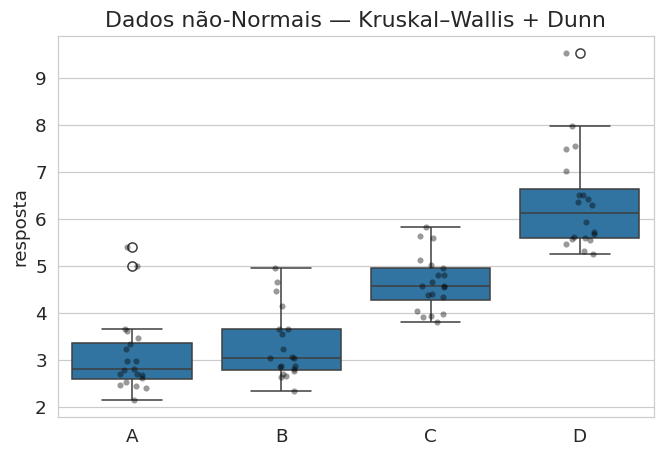

In [15]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.boxplot(data=dados_np, x='grupo', y='resposta', ax=ax)
sns.stripplot(data=dados_np, x='grupo', y='resposta', ax=ax,
              color='black', alpha=0.4, size=4)
ax.set_title('Dados não-Normais — Kruskal–Wallis + Dunn')
ax.set_xlabel(''); ax.set_ylabel('resposta');

## 4. Planejamento fatorial 2 × 2

Dois fatores cruzados, dois níveis cada → quatro grupos. Analisado por
**ANOVA two-way**: decompõe a variância em três fontes além do resíduo:

- **efeito principal de A** (média sobre todos os níveis de B)
- **efeito principal de B**
- **interação A × B** (o efeito de A muda com o nível de B)

### 4.1 Simulando um 2 × 2

Imaginem um estudo: efeito de **dose** (baixa / alta) e **dieta**
(padrão / restrita) sobre um marcador inflamatório.

In [16]:
np.random.seed(3)
n = 12   # por célula
doses   = ['baixa', 'alta']
dietas  = ['padrão', 'restrita']

# médias verdadeiras (com interação)
mu = {('baixa', 'padrão'): 10, ('alta', 'padrão'): 12,
      ('baixa', 'restrita'): 11, ('alta', 'restrita'): 16}

linhas = []
for d in doses:
    for di in dietas:
        for _ in range(n):
            linhas.append({'dose': d, 'dieta': di,
                           'marcador': np.random.normal(mu[(d, di)], 1.8)})
df = pd.DataFrame(linhas)
df.groupby(['dose', 'dieta'])['marcador'].mean().round(2)

dose   dieta   
alta   padrão      11.30
       restrita    15.09
baixa  padrão       9.72
       restrita    11.05
Name: marcador, dtype: float64

### 4.2 ANOVA two-way

In [17]:
mod = smf.ols('marcador ~ C(dose) * C(dieta)', data=df).fit()
tab = sm.stats.anova_lm(mod, typ=2)
tab.round(4)

,sum_sq,df,F,PR(>F)
C(dose),94.6115,1.0,29.2736,0.0000
C(dieta),78.5234,1.0,24.2958,0.0000
C(dose):C(dieta),18.1331,1.0,5.6105,0.0223
Residual,142.2070,44.0,NaN,NaN


Lendo a tabela:

- linha **C(dose)** → efeito principal da dose
- linha **C(dieta)** → efeito principal da dieta
- linha **C(dose):C(dieta)** → INTERAÇÃO

Se a interação é significativa, os efeitos principais sozinhos contam
uma história incompleta — é preciso reportar as médias por **célula**.

### 4.3 Interaction plot

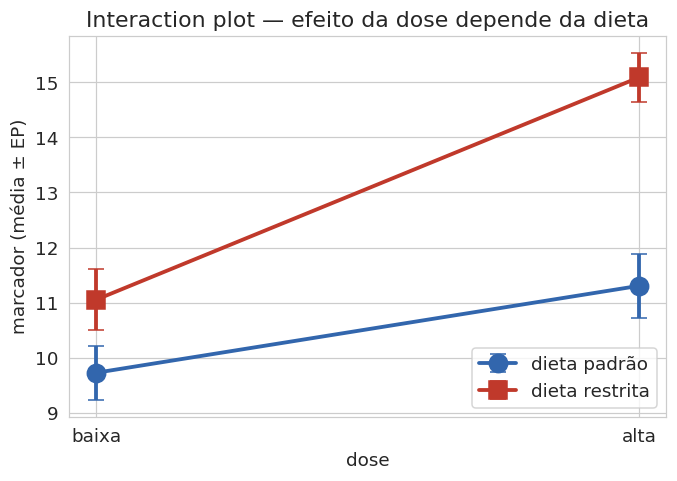

In [18]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for di, marcador, cor in [('padrão',   'o', '#3266ad'),
                          ('restrita', 's', '#c0392b')]:
    sub = df[df['dieta'] == di].groupby('dose')['marcador'].agg(['mean', 'sem'])
    sub = sub.reindex(['baixa', 'alta'])
    ax.errorbar(sub.index, sub['mean'], yerr=sub['sem'],
                marker=marcador, lw=2.5, ms=12, capsize=5,
                color=cor, label=f'dieta {di}')
ax.set_xlabel('dose'); ax.set_ylabel('marcador (média ± EP)')
ax.set_title('Interaction plot — efeito da dose depende da dieta')
ax.legend(loc='lower right');

As linhas **não são paralelas** → a interação dose × dieta é real:
a dieta restrita amplifica o efeito da dose alta.

### 4.4 Boxplots por célula

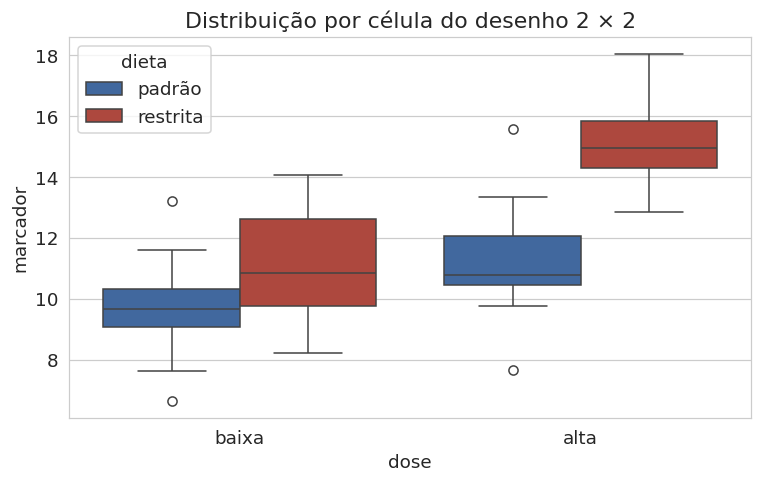

In [19]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(data=df, x='dose', y='marcador', hue='dieta',
            order=['baixa', 'alta'], ax=ax,
            palette={'padrão': '#3266ad', 'restrita': '#c0392b'})
ax.set_title('Distribuição por célula do desenho 2 × 2')
ax.set_xlabel('dose'); ax.set_ylabel('marcador');

## Encerramento

**Recapitulando:**

- O cálculo amostral *precede* a coleta (sempre)
- A escolha do **pós-teste** depende da pergunta — não escolha o que dá menor p
- Tukey é genérico; Dunnett é mais poderoso quando o interesse é × controle;
  Bonferroni é honesto para poucas comparações planejadas
- Não-paramétrico: troque ANOVA → Kruskal–Wallis e Tukey → Dunn
- Planejamento fatorial responde a múltiplas perguntas com o mesmo n
  *e* revela interações (ANOVA two-way)

Para mais detalhes teóricos, ver `17_design_experimental.md` e `18_escolha_do_teste.md`.